# Security filters · 2. Demand scenarios

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ula-uab/lscm-decision-making/blob/main/cases/security_filters/notebooks/02_demand_scenarios.ipynb)

The presentation curve depends on assumptions about each flight: how full it is, how many passengers connect to another flight (they do not go through the filters), when its passengers arrive, and whether some of them arrive all together by bus. A **demand scenario** is a set of those assumptions, written as a few **rules**. Each scenario gives one curve.

In [1]:
# In Google Colab, install the package from GitHub (it takes a few seconds).
# On your own computer, install the repository environment instead (see README).
import sys
if "google.colab" in sys.modules:
    %pip install -q "git+https://github.com/ula-uab/lscm-decision-making#subdirectory=cases/security_filters"

In [2]:
import security_filters as sf
from security_filters.plots import plot_curves, plot_profiles

schedule = sf.read_schedule()
day = sf.examples.DAY
flights = sf.flights_for_curve(schedule, day)
print(f"{day}: {len(flights)} flights, {flights['airline'].nunique()} airlines")

2008-07-19: 440 flights, 57 airlines


## 1. Arrival profiles by type of flight

Passengers behave differently depending on the flight. Each profile here is defined by two numbers: the **mean** time before departure at which passengers arrive and its **standard deviation**, in minutes. The values are provisional orders of magnitude.

In [3]:
profiles = sf.profile_library()
{name: (p.mean_min, p.sd_min, p.description) for name, p in sf.PRESETS.items()}

{'business': (55, 18, 'Business destinations: late and punctual arrivals'),
 'leisure': (100, 30, 'Holiday and charter flights'),
 'low_cost': (85, 25, 'Low-cost carriers: online check-in, hand luggage'),
 'long_haul': (150, 40, 'Long-haul and intercontinental flights'),
 'wave': (95, 6, 'Passengers brought together by bus (tour operator, cruise)')}

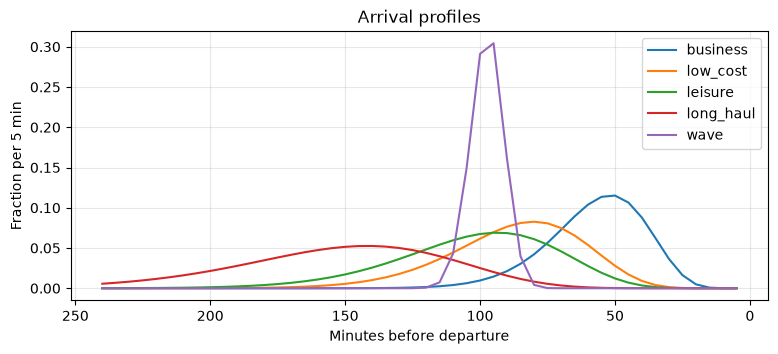

In [4]:
plot_profiles(profiles, ["business", "low_cost", "leisure", "long_haul", "wave"]);

You can add your own profile, for instance for a cruise terminal:

```python
patterns = dict(sf.PRESETS, cruise=sf.ArrivalPattern(180, 20))
profiles = sf.profile_library(patterns)
```

## 2. Assumptions as rules

Each rule says **which flights** it applies to (`airline`, `destination`, `flight`, `departure_from`, `departure_to`) and **which values** it sets:

| Value | Meaning |
|---|---|
| `load_factor` | fraction of seats occupied (0 to 1) |
| `transfer_share` | fraction of passengers who connect and do not go through the filters |
| `advance_min` | minutes by which passengers arrive earlier than the profile says (tour-operator or cruise buses) |
| `profile` | arrival profile |

Rules are applied in order; the last matching rule wins. Write them from the most general to the most specific.

In [5]:
rules = [
    {"load_factor": 0.85, "profile": "leisure"},                             # every flight
    {"destination": sf.examples.BUSINESS_DESTINATIONS, "profile": "business"},
    {"airline": sf.examples.LOW_COST_AIRLINES, "load_factor": 0.90, "profile": "low_cost"},
    {"airline": ["AEA", "IBE"], "load_factor": 0.80, "transfer_share": 0.30},
    {"airline": "TOM", "load_factor": 0.95, "profile": "wave", "advance_min": 55},
]
assumptions = sf.apply_rules(flights, rules)
assumptions[["flight", "departure", "destination", "seats", "load_factor",
             "transfer_share", "advance_min", "profile", "passengers", "rules"]].head(10)

,flight,departure,destination,seats,load_factor,transfer_share,advance_min,profile,passengers,rules
0,TOM3472,00:15,LGW,189,0.95,0.0,55,wave,179.55,1 5
1,TCX145L,01:20,BHX,235,0.90,0.0,0,low_cost,211.50,1 3
2,BMA7254,01:50,MAN,156,0.85,0.0,0,leisure,132.60,1
3,JKK4369,03:15,ETZ,167,0.85,0.0,0,leisure,141.95,1
4,BAW2703,03:40,LGW,110,0.85,0.0,0,leisure,93.50,1
5,AEA547,04:00,LYS,186,0.80,0.3,0,leisure,104.16,1 4
6,JKK3863,04:00,NOC,170,0.85,0.0,0,leisure,144.50,1
7,JKK3205,04:20,BFS,170,0.85,0.0,0,leisure,144.50,1
8,BER4354,04:25,ALC,100,0.90,0.0,0,low_cost,90.00,1 3
9,TVS345,04:25,BRQ,199,0.85,0.0,0,leisure,169.15,1


The table has one row per flight, like the sheet "Paso2" of the original workbook. The column `rules` shows which rules matched each flight. The Thomson flights, for example:

In [6]:
assumptions[assumptions["airline"] == "TOM"][["flight", "departure", "destination", "passengers",
                                                "profile", "advance_min", "rules"]]

,flight,departure,destination,passengers,profile,advance_min,rules
0,TOM3472,00:15,LGW,179.55,wave,55,1 5
125,TOM4814,09:15,BHX,311.60,wave,55,1 5
139,TOM1796,09:40,MAN,311.60,wave,55,1 5
161,TOM2896,10:40,CWL,216.60,wave,55,1 5
166,TOM2852,10:50,NCL,223.25,wave,55,1 5
289,TOM1404,16:15,LGW,311.60,wave,55,1 5
313,TOM1114,17:10,MAN,179.55,wave,55,1 5
317,TOM1878,17:25,EMA,176.70,wave,55,1 5
386,TOM4924,19:55,GLA,223.25,wave,55,1 5
409,TOM3468,20:55,LTN,223.25,wave,55,1 5


In [7]:
sf.summary_by_airline(assumptions).head(10).round(0)

,flights,seats,passengers
airline,,,
BER,75,13620,12258.0
JKK,40,6377,5420.0
AEA,29,5547,3106.0
TCX,21,4645,4180.0
FCA,20,4364,3709.0
EZY,24,3834,3451.0
TOM,15,3526,3350.0
HLX,18,3265,2775.0
CFG,12,2588,2200.0


Rules can also be kept in a CSV or Excel file, one rule per row, and read with `sf.read_rules("my_rules.csv")`.

## 3. Three scenarios

`sf.examples.demand_scenarios()` gives three scenarios, from the simplest to the most detailed. The third one adds a cruise ship: its passengers flying to the UK between 16:00 and 18:00 are brought to the airport by bus around 13:00.

In [8]:
scenarios = sf.examples.demand_scenarios()
for s in scenarios:
    print(f"{s.name}: {s.description}")
    for rule in s.rules:
        print("   ", rule)

base: Every flight 85 % full, holiday passengers
    {'load_factor': 0.85, 'profile': 'leisure'}
by flight type: Profile by type of flight, connections at hubs, tour-operator buses
    {'load_factor': 0.85, 'profile': 'leisure'}
    {'destination': ['MAD', 'BCN', 'BIO', 'VLC', 'SVQ', 'AGP', 'LIS', 'CDG', 'ORY', 'FRA', 'MUC', 'ZRH', 'GVA', 'BRU', 'AMS', 'FCO', 'MXP', 'LHR'], 'profile': 'business'}
    {'airline': ['RYR', 'EZY', 'VLG', 'GWI', 'BER', 'NLY', 'TCX'], 'load_factor': 0.9, 'profile': 'low_cost'}
    {'airline': ['AEA', 'IBE'], 'load_factor': 0.8, 'transfer_share': 0.3}
    {'airline': 'TOM', 'load_factor': 0.95, 'profile': 'wave', 'advance_min': 55}
cruise day: As 'by flight type', plus a cruise ship whose passengers to the UK (flights 16:00-18:00) arrive together by bus around 13:00
    {'load_factor': 0.85, 'profile': 'leisure'}
    {'destination': ['MAD', 'BCN', 'BIO', 'VLC', 'SVQ', 'AGP', 'LIS', 'CDG', 'ORY', 'FRA', 'MUC', 'ZRH', 'GVA', 'BRU', 'AMS', 'FCO', 'MXP', 'LHR'], 

base              65673.0
by flight type    65344.0
cruise day        65344.0
dtype: float64


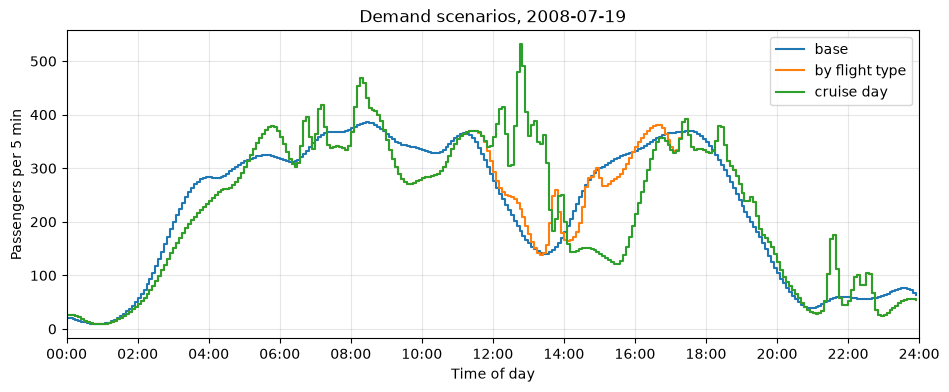

In [9]:
curves = sf.demand_curves(scenarios, flights, profiles)
print(curves.sum().round(0))
plot_curves({name: curves[name] for name in curves}, title=f"Demand scenarios, {day}");

In [10]:
sf.hourly(curves).round(0).T

hour,00:00,01:00,02:00,03:00,04:00,05:00,06:00,07:00,08:00,09:00,...,14:00,15:00,16:00,17:00,18:00,19:00,20:00,21:00,22:00,23:00
base,165.0,299.0,1387.0,3027.0,3501.0,3849.0,3861.0,4383.0,4556.0,4153.0,...,2958.0,3803.0,4200.0,4392.0,3580.0,2087.0,760.0,623.0,692.0,848.0
by flight type,206.0,260.0,1068.0,2358.0,3153.0,4218.0,4093.0,4285.0,4982.0,3517.0,...,2700.0,3469.0,4385.0,4184.0,3912.0,2412.0,854.0,881.0,847.0,551.0
cruise day,206.0,260.0,1068.0,2358.0,3153.0,4218.0,4093.0,4285.0,4982.0,3517.0,...,1832.0,1688.0,3686.0,4170.0,3912.0,2412.0,854.0,881.0,847.0,551.0


## 4. Try it yourself

- Write a scenario with a lower load factor for the low-cost airlines.
- Move the cruise buses one hour earlier (`advance_min`).
- Which assumption changes the peak of the morning most?

Notebook 3 uses these curves to decide how many lanes to open.